In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Problem 1

In [3]:
df_zillow = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-zillow-house-prices/data_zillow_house_prices.csv")
df_interest = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-interest-rates/data_interest_rates.csv")
print(f"ZIllow shape: {df_zillow.shape}")
print(f"Interest shape: {df_interest.shape}")

ZIllow shape: (893, 277)
Interest shape: (2685, 2)


In [4]:
df_zillow.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0


In [5]:
df_interest.head()

,DATE,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [6]:
nan_zillow = df_zillow.isna().sum()
print(f"NaN in Zillow: {nan_zillow[nan_zillow > 0]}")

NaN in Zillow: StateName       1
2000-01-31    457
2000-02-29    456
2000-03-31    455
2000-04-30    453
             ... 
2021-11-30      2
2021-12-31      7
2022-01-31      3
2022-02-28      3
2022-03-31      2
Length: 268, dtype: int64


In [7]:
print(f"Regions: {df_zillow['RegionType'].unique()}")

Regions: ['country' 'msa']


In [8]:
nan_interest = df_interest.isna().sum()
print(f"NaN in interest: {nan_interest[nan_interest > 0]}")

NaN in interest: Series([], dtype: int64)


In [9]:
print(f"{df_interest["MORTGAGE30US"].describe()}")

count    2685.000000
mean        7.762004
std         3.285851
min         2.650000
25%         5.080000
50%         7.430000
75%         9.550000
max        18.630000
Name: MORTGAGE30US, dtype: float64


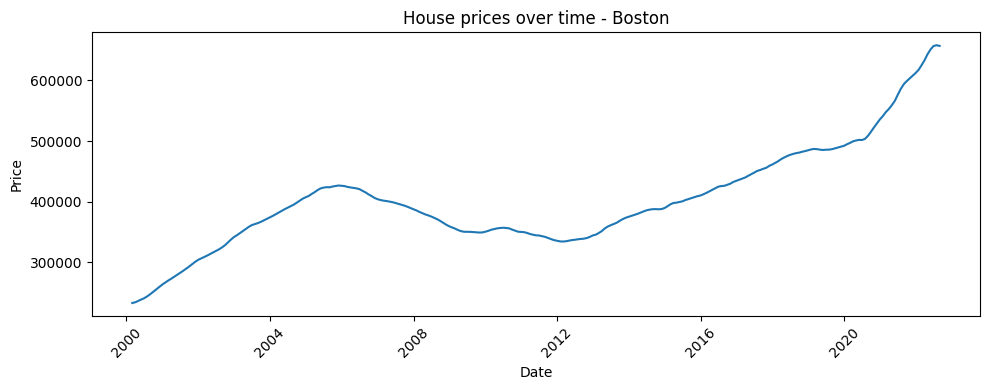

In [10]:
boston = df_zillow[df_zillow["RegionName"] == "Boston, MA"]

ts = boston.iloc[0, 6:] 

ts.index = pd.to_datetime(ts.index) 
ts = ts.sort_index()

plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values)
plt.title("House prices over time - Boston")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

ts = boston.iloc[0, 5:]
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index()

ts_2010_2017 = ts.loc["2010-01-01":"2017-12-31"]

result = adfuller(ts_2010_2017)
p_value   = result[1]

print(f"p-value: {p_value}")

p-value: 0.978724326139202


<Figure size 800x400 with 0 Axes>

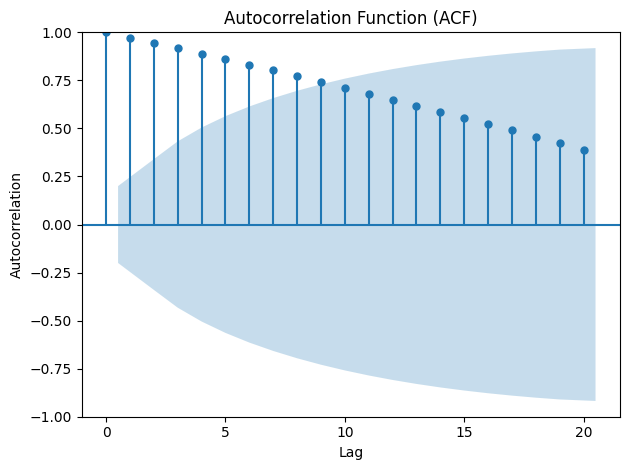

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(8, 4))
plot_acf(ts_2010_2017)  
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

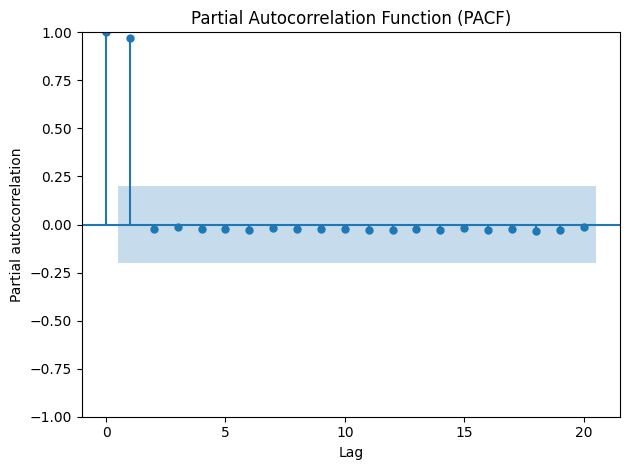

In [13]:
plt.figure(figsize=(8, 4))
plot_pacf(ts_2010_2017, lags=20, method="ywm") 
plt.xlabel("Lag")
plt.ylabel("Partial autocorrelation")
plt.title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

# Problem 2

## Model Calibration

In [14]:
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg

ts = boston.iloc[0, 5:]
ts.index = pd.to_datetime(ts.index)
ts = ts.sort_index().astype(float)
ts = ts.loc["2010-01-01":"2019-12-31"]

y = ts.values
T = len(y)
t = np.arange(1, T+1, dtype=float)

X = sm.add_constant(t)          
ols = sm.OLS(y, X).fit()
trend_hat = ols.predict(X)
ts_detr = pd.Series(y - trend_hat, index=ts.index)
 

train_detr = ts_detr.loc["2010-01-01":"2017-12-31"]

def mse_train(y_series, p):
    model = AutoReg(y_series, lags=p, hold_back=p, old_names=False)
    res = model.fit()
    y_hat = res.predict(start=0, end=len(y_series)-1)
    y_true = y_series
    mse = np.mean((y_true - y_hat)**2)
    return mse


mses = {p: mse_train(train_detr, p) for p in range(1, 6)}
round(mses[1] / 1_000_000, 1), min(mses, key=mses.get)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

(np.float64(1.8), 5)

In [15]:
mse1 = mses[1]               
mse1_million = mse1 / 1_000_000
round(mse1_million, 1)

np.float64(1.8)

In [16]:
best_p = min(mses, key=mses.get)
best_p

5

In [17]:
d_45 = mses[4] - mses[5]
d_34 = mses[3] - mses[4]
d_23 = mses[2] - mses[3]
d_12 = mses[1] - mses[2]

d_45, d_34, d_23, d_12

(np.float64(107203.52825248236),
 np.float64(1965.9374762791558),
 np.float64(-3132.389771454851),
 np.float64(1350123.749746654))

The optimal choice is $p = 2$ because the training MSE drops sharply from $p = 1$ to $p = 2$, while higher orders only bring negligible or no improvement, so AR(2) is the most parsimonious model.

## Time-Series Prediction

In [18]:
train_detr = ts_detr.loc["2010-01-01":"2017-12-31"]
test_detr  = ts_detr.loc["2018-01-01":"2019-12-31"]

train_orig = ts.loc["2010-01-01":"2017-12-31"]
test_orig  = ts.loc["2018-01-01":"2019-12-31"]

p_opt = best_p   

In [19]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd

y = ts.values
T = len(y)
t = np.arange(1, T+1, dtype=float)

X = sm.add_constant(t)
ols = sm.OLS(y, X).fit()
trend_hat = ols.predict(X)

ts_detr = pd.Series(y - trend_hat, index=ts.index)

train_detr = ts_detr.loc["2010-01-31":"2017-12-31"]
test_detr  = ts_detr.loc["2018-01-31":"2019-12-31"]

def mse_train(y_series, p):
    model = ARIMA(y_series, order=(p,0,0))
    res   = model.fit()
    fitted = res.predict(start=0, end=len(y_series)-1)
    return np.mean((y_series.values - fitted)**2)

mses  = {p: mse_train(train_detr, p) for p in range(1,6)}
p_opt = min(mses, key=mses.get)

print("p_opt:", p_opt)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

p_opt: 5


In [20]:
model_long = ARIMA(train_detr, order=(p_opt, 0, 0))
res_long   = model_long.fit()

pred_detr_long = res_long.forecast(steps=len(test_detr))
pred_detr_long = pd.Series(pred_detr_long, index=test_detr.index)

y_test = test_detr.values

idx_may2018 = test_detr.index.get_loc("2018-05-31")

err_may_long = (y_test[idx_may2018] - pred_detr_long.iloc[idx_may2018])**2
mse_may_long_thousand = round(err_may_long / 1_000_000, 2)

mse_test_long_thousand = round(
    np.mean((y_test - pred_detr_long.values)**2) / 1_000_000, 2
)

print("MSE May 2018 long-term (k):", mse_may_long_thousand)
print("MSE-test long-term (k):", mse_test_long_thousand)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


MSE May 2018 long-term (k): 27.08
MSE-test long-term (k): 20.52


In [21]:
history = train_detr.copy()
pred_detr_short = []

for date in test_detr.index:
    model = ARIMA(history, order=(p_opt, 0, 0))
    res   = model.fit()
    pred_resid = res.forecast(steps=1).iloc[0]
    pred_detr_short.append(pred_resid)
    history = pd.concat([history, test_detr.loc[[date]]])

pred_detr_short = pd.Series(pred_detr_short, index=test_detr.index)

err_may_short = (y_test[idx_may2018] - pred_detr_short.iloc[idx_may2018])**2
mse_may_short_thousand = round(err_may_short / 1_000_000, 2)

mse_test_short_thousand = round(
    np.mean((y_test - pred_detr_short.values)**2) / 1_000_000, 2
)

print("MSE May 2018 short-term (k):", mse_may_short_thousand)
print("MSE-test short-term (k):", mse_test_short_thousand)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

MSE May 2018 short-term (k): 0.0
MSE-test short-term (k): 0.3


# Problem 3

In [22]:
print(df_interest.columns)

Index(['DATE', 'MORTGAGE30US'], dtype='object')


In [23]:
df_ir = df_interest.copy()

df_ir["DATE"] = pd.to_datetime(df_ir["DATE"])
df_ir = df_ir.set_index("DATE")

ir_series = df_ir["MORTGAGE30US"]

ir_monthly = ir_series.resample("M").mean()

ir_monthly = ir_monthly.loc[ts_detr.index]

exog_train = ir_monthly.loc["2010-01-31":"2017-12-31"]
exog_test  = ir_monthly.loc["2018-01-31":"2019-12-31"]

In [24]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

def mse_train_arx(y_train, exog_train, p):
    model = ARIMA(y_train, exog=exog_train, order=(p,0,0), trend="n")
    res   = model.fit()
    fitted = res.predict(start=0, end=len(y_train)-1, exog=exog_train)
    return np.mean((y_train.values - fitted)**2)

mses_train_arx = {p: mse_train_arx(train_detr, exog_train, p) for p in range(1,5)}
p_opt_train_arx = min(mses_train_arx, key=mses_train_arx.get)
print("best p (train) ARX:", p_opt_train_arx)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

best p (train) ARX: 1


In [25]:
def mse_test_arx_short(y_train, y_test, exog_train, exog_test, p):
    history_y = y_train.copy()
    history_x = exog_train.copy()
    preds = []

    for date in exog_test.index:
        model = ARIMA(history_y, exog=history_x, order=(p,0,0), trend="n")
        res   = model.fit()
        # exog del mese corrente
        x_curr = exog_test.loc[[date]]
        pred = res.forecast(steps=1, exog=x_curr).iloc[0]
        preds.append(pred)
        # aggiorna history con valore osservato e exog corrente
        history_y = pd.concat([history_y, y_test.loc[[date]]])
        history_x = pd.concat([history_x, x_curr])

    preds = np.array(preds)
    y_true = y_test.values
    mse = np.mean((y_true - preds)**2)
    return mse

mses_test_arx = {
    p: mse_test_arx_short(train_detr, test_detr, exog_train, exog_test, p)
    for p in range(1,5)
}

print(mses_test_arx)
p_opt_test_arx = min(mses_test_arx, key=mses_test_arx.get)
print("best p (test) ARX:", p_opt_test_arx)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

{1: np.float64(848920.0819959898), 2: np.float64(279982.63532947813), 3: np.float64(285630.04916872195), 4: np.float64(269330.5760467356)}
best p (test) ARX: 4


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [26]:
print("AR best p (train):", best_p)
print("AR train MSE(best_p):", mses[best_p])

print("ARX best p (test):", p_opt_test_arx)
print("ARX train MSE(best p test):", mses_train_arx[p_opt_test_arx])
print("ARX test  MSE(best p test):", mses_test_arx[p_opt_test_arx])

AR best p (train): 5
AR train MSE(best_p): 16280272.808460446
ARX best p (test): 4
ARX train MSE(best p test): 15660423.978540279
ARX test  MSE(best p test): 269330.5760467356


In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

y = ts.values
T = len(y)
t = np.arange(1, T+1, dtype=float)

X = sm.add_constant(t)
ols = sm.OLS(y, X).fit()
trend_hat = ols.predict(X)

ts_detr = pd.Series(y - trend_hat, index=ts.index)

# train / test sui residui
train_detr = ts_detr.loc["2010-01-31":"2017-12-31"]
test_detr  = ts_detr.loc["2018-01-31":"2019-12-31"]

df_ir = df_interest.copy()
df_ir["DATE"] = pd.to_datetime(df_ir["DATE"])
df_ir = df_ir.set_index("DATE")
ir_series = df_ir["MORTGAGE30US"]

ir_monthly = ir_series.resample("M").mean()
ir_monthly = ir_monthly.loc[ts_detr.index]

exog_train = ir_monthly.loc["2010-01-31":"2017-12-31"]
exog_test  = ir_monthly.loc["2018-01-31":"2019-12-31"]

ps_ar   = [1, 2, 3, 4, 5]
ps_arx  = [1, 2, 3, 4]
ps_armax = [1, 2, 3, 4]
qs_armax = [1, 5, 10]

def mse_train_ar(y_train, p):
    model = ARIMA(y_train, order=(p,0,0))
    res   = model.fit()
    fitted = res.predict(start=0, end=len(y_train)-1)
    return np.mean((y_train.values - fitted)**2)

def mse_test_ar_short(y_train, y_test, p):
    history = y_train.copy()
    preds = []
    for date in y_test.index:
        model = ARIMA(history, order=(p,0,0))
        res   = model.fit()
        pred = res.forecast(steps=1).iloc[0]
        preds.append(pred)
        history = pd.concat([history, y_test.loc[[date]]])
    preds = np.array(preds)
    return np.mean((y_test.values - preds)**2)

mses_train_ar = {p: mse_train_ar(train_detr, p) for p in ps_ar}
best_p_ar_train = min(mses_train_ar, key=mses_train_ar.get)

mses_test_ar = {p: mse_test_ar_short(train_detr, test_detr, p) for p in ps_ar}
best_p_ar_test = min(mses_test_ar, key=mses_test_ar.get)

print("=== AR(p) ===")
print("MSE train AR:", mses_train_ar)
print("Best p train AR:", best_p_ar_train, "MSE:", mses_train_ar[best_p_ar_train])
print("MSE test AR:", mses_test_ar)
print("Best p test AR:", best_p_ar_test, "MSE:", mses_test_ar[best_p_ar_test])
print()

def mse_train_arx(y_train, x_train, p):
    model = ARIMA(y_train, exog=x_train, order=(p,0,0), trend="n")
    res   = model.fit()
    fitted = res.predict(start=0, end=len(y_train)-1, exog=x_train)
    return np.mean((y_train.values - fitted)**2)

def mse_test_arx_short(y_train, y_test, x_train, x_test, p):
    history_y = y_train.copy()
    history_x = x_train.copy()
    preds = []
    for date in y_test.index:
        model = ARIMA(history_y, exog=history_x, order=(p,0,0), trend="n")
        res   = model.fit()
        x_curr = x_test.loc[[date]]
        pred = res.forecast(steps=1, exog=x_curr).iloc[0]
        preds.append(pred)
        history_y = pd.concat([history_y, y_test.loc[[date]]])
        history_x = pd.concat([history_x, x_curr])
    preds = np.array(preds)
    return np.mean((y_test.values - preds)**2)

mses_train_arx = {p: mse_train_arx(train_detr, exog_train, p) for p in ps_arx}
mses_test_arx  = {p: mse_test_arx_short(train_detr, test_detr,
                                        exog_train, exog_test, p)
                  for p in ps_arx}

best_p_arx_train = min(mses_train_arx, key=mses_train_arx.get)
best_p_arx_test  = min(mses_test_arx, key=mses_test_arx.get)

print("=== ARX(p) ===")
print("MSE train ARX:", mses_train_arx)
print("Best p train ARX:", best_p_arx_train,
      "MSE:", mses_train_arx[best_p_arx_train])
print("MSE test ARX:", mses_test_arx)
print("Best p test ARX:", best_p_arx_test,
      "MSE:", mses_test_arx[best_p_arx_test])
print()

def mse_train_armax_fn(y_train, x_train, p, q):
    model = ARIMA(y_train, exog=x_train, order=(p,0,q), trend="n")
    res   = model.fit()
    fitted = res.predict(start=0, end=len(y_train)-1, exog=x_train)
    return np.mean((y_train.values - fitted)**2)

def mse_test_armax_short_fn(y_train, y_test, x_train, x_test, p, q):
    history_y = y_train.copy()
    history_x = x_train.copy()
    preds = []
    for date in y_test.index:
        model = ARIMA(history_y, exog=history_x, order=(p,0,q), trend="n")
        res   = model.fit()
        x_curr = x_test.loc[[date]]
        pred = res.forecast(steps=1, exog=x_curr).iloc[0]
        preds.append(pred)
        history_y = pd.concat([history_y, y_test.loc[[date]]])
        history_x = pd.concat([history_x, x_curr])
    preds = np.array(preds)
    return np.mean((y_test.values - preds)**2)

mse_train_armax = {}
mse_test_armax  = {}

for p in ps_armax:
    for q in qs_armax:
        try:
            mse_tr = mse_train_armax_fn(train_detr, exog_train, p, q)
            mse_ts = mse_test_armax_short_fn(train_detr, test_detr,
                                             exog_train, exog_test, p, q)
            mse_train_armax[(p,q)] = mse_tr
            mse_test_armax[(p,q)]  = mse_ts
        except Exception as e:
            print(f"ARMAX({p},{q}) failed:", e)

print("=== ARMAX(p,q) ===")
print("MSE train ARMAX:", mse_train_armax)
print("MSE test ARMAX :", mse_test_armax)

best_pq_train = min(mse_train_armax, key=mse_train_armax.get)
best_pq_test  = min(mse_test_armax, key=mse_test_armax.get)

print("Best (p,q) train ARMAX:", best_pq_train,
      "MSE:", mse_train_armax[best_pq_train])
print("Best (p,q) test  ARMAX:", best_pq_test,
      "MSE:", mse_test_armax[best_pq_test])


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

=== AR(p) ===
MSE train AR: {1: np.float64(18097594.281665076), 2: np.float64(16392094.769269714), 3: np.float64(16391653.49318023), 4: np.float64(16390835.026350133), 5: np.float64(16280272.808460446)}
Best p train AR: 5 MSE: 16280272.808460446
MSE test AR: {1: np.float64(1112988.3866545071), 2: np.float64(277188.12859520054), 3: np.float64(280382.6066892229), 4: np.float64(268297.30789321073), 5: np.float64(304359.5587083208)}
Best p test AR: 4 MSE: 268297.30789321073



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

=== ARX(p) ===
MSE train ARX: {1: np.float64(9176905.173554027), 2: np.float64(15661450.812545182), 3: np.float64(15659578.601647874), 4: np.float64(15660423.978540279)}
Best p train ARX: 1 MSE: 9176905.173554027
MSE test ARX: {1: np.float64(848920.0819959898), 2: np.float64(279982.63532947813), 3: np.float64(285630.04916872195), 4: np.float64(269330.5760467356)}
Best p test ARX: 4 MSE: 269330.5760467356



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnin

=== ARMAX(p,q) ===
MSE train ARMAX: {(1, 1): np.float64(10873760.926845198), (1, 5): np.float64(15511681.231176227), (1, 10): np.float64(15544280.851979261), (2, 1): np.float64(15659488.82837451), (2, 5): np.float64(15524998.786202252), (2, 10): np.float64(15509017.027275326), (3, 1): np.float64(15641835.760954581), (3, 5): np.float64(15517188.915651405), (3, 10): np.float64(15504806.713194065), (4, 1): np.float64(15625292.977007486), (4, 5): np.float64(15513221.528834319), (4, 10): np.float64(15489068.083063543)}
MSE test ARMAX : {(1, 1): np.float64(707829.7893434215), (1, 5): np.float64(295546.5241354697), (1, 10): np.float64(287065.6523248587), (2, 1): np.float64(280703.75404916744), (2, 5): np.float64(266247.1970305966), (2, 10): np.float64(290046.0382956153), (3, 1): np.float64(295631.5206844868), (3, 5): np.float64(305491.8872507081), (3, 10): np.float64(340683.85762648913), (4, 1): np.float64(296303.6433566953), (4, 5): np.float64(308945.2966754571), (4, 10): np.float64(329896.7

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [28]:
best_pq_train[0], best_pq_train[1], best_pq_test[0], best_pq_test[1]

(1, 1, 2, 5)